# 🏗️ Construction Cost Prediction Pipeline
## Best-Practices ML Regression Pipeline

**Target:** `construction_cost_per_m2_usd`

**Pipeline:** EDA → Feature Engineering → Preprocessing → Model Training (9 models) → Hyperparameter Tuning → Evaluation & Visualization → Model Persistence

**Models:** Ridge, Lasso, ElasticNet, SVR, RandomForest, GradientBoosting, XGBoost, LightGBM, CatBoost

In [ ]:
# ============================================================
# IMPORTS & CONFIGURATION
# ============================================================
import os
import warnings
import json
import time
import subprocess

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    KFold, cross_val_score, cross_val_predict,
    RandomizedSearchCV, learning_curve, validation_curve
)
from sklearn.preprocessing import (
    StandardScaler, OrdinalEncoder, OneHotEncoder, TargetEncoder
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score
)
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.svm import SVR
from sklearn.ensemble import (
    RandomForestRegressor, GradientBoostingRegressor
)
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
import joblib
from scipy import stats

# Configuration
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 150
RANDOM_STATE = 42
CV_FOLDS = 5
N_ITER = 30  # RandomizedSearchCV iterations

# Create output directories
os.makedirs('plots', exist_ok=True)
os.makedirs('saved_models', exist_ok=True)

# Detect GPU / CUDA
try:
    result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
    HAS_GPU = result.returncode == 0
    if HAS_GPU:
        # Print just the GPU name
        for line in result.stdout.split('\n'):
            if 'NVIDIA' in line and 'Driver' not in line:
                print(f"✅ GPU detected: {line.strip()}")
                break
        print("✅ CUDA will be used for XGBoost, LightGBM, CatBoost")
except FileNotFoundError:
    HAS_GPU = False

if not HAS_GPU:
    print("⚠️ No GPU detected — all models will run on CPU")

print(f"\n📋 Configuration: CV_FOLDS={CV_FOLDS}, N_ITER={N_ITER}, RANDOM_STATE={RANDOM_STATE}")
print(f"📁 Plots → plots/  |  Models → saved_models/")

✅ GPU detected: |   0  NVIDIA GeForce RTX 3050 ...    On  |   00000000:01:00.0 Off |                  N/A |
✅ CUDA will be used for XGBoost, LightGBM, CatBoost

📋 Configuration: CV_FOLDS=5, N_ITER=30, RANDOM_STATE=42
📁 Plots → plots/  |  Models → saved_models/


## Phase 1: Data Loading & EDA

In [ ]:
# ============================================================
# LOAD & INSPECT DATA
# ============================================================
df = pd.read_csv('train_tabular.csv')

print(f"Shape: {df.shape}")
print(f"\nDuplicates: {df.duplicated().sum()}")
print(f"\n--- Missing Values ---")
print(df.isnull().sum())
print(f"\n--- Data Types ---")
print(df.dtypes)
df.head()

Shape: (1024, 23)

Duplicates: 0

--- Missing Values ---
data_id                            0
geolocation_name                   0
quarter_label                      0
country                            0
year                               0
deflated_gdp_usd                   0
us_cpi                             0
developed_country                  0
landlocked                         0
region_economic_classification     0
access_to_airport                  0
access_to_port                     0
access_to_highway                  0
access_to_railway                  0
straight_distance_to_capital_km    0
seismic_hazard_zone                0
flood_risk_class                   0
tropical_cyclone_wind_risk         4
tornadoes_wind_risk                0
koppen_climate_zone                0
sentinel2_tiff_file_name           0
viirs_tiff_file_name               0
construction_cost_per_m2_usd       0
dtype: int64

--- Data Types ---
data_id                                str
geolocation_name

,data_id,geolocation_name,quarter_label,country,year,deflated_gdp_usd,us_cpi,developed_country,landlocked,region_economic_classification,...,access_to_railway,straight_distance_to_capital_km,seismic_hazard_zone,flood_risk_class,tropical_cyclone_wind_risk,tornadoes_wind_risk,koppen_climate_zone,sentinel2_tiff_file_name,viirs_tiff_file_name,construction_cost_per_m2_usd
0,LP81L,Dinagat Islands,2019-Q3,Philippines,2019,2.996821e+11,117.689915,No,No,Lower-middle income,...,No,770.0,Moderate,Yes,High,Very Low,Af,sentinel_2_dinagat_islands_2019-Q3.tif,viirs_dinagat_islands_2019-Q3.tif,129.997420
1,E7EOB,29000 Nara,2024-Q2,Japan,2024,3.928801e+12,143.968241,Yes,Yes,High income,...,Yes,370.0,Moderate,Yes,Low,Very Low,Cfa,sentinel_2_29000_nara_2024-Q2.tif,viirs_29000_nara_2024-Q2.tif,1567.878774
2,WAOUA,05000 Akita,2020-Q1,Japan,2020,4.069008e+12,118.435291,Yes,No,High income,...,Yes,450.0,Moderate,Yes,Low,Very Low,Dfa,sentinel_2_05000_akita_2020-Q1.tif,viirs_05000_akita_2020-Q1.tif,2009.827701
3,2IZ5P,Cotabato,2020-Q4,Philippines,2020,2.912443e+11,119.402476,No,Yes,Lower-middle income,...,No,870.0,High,Yes,Moderate,Very Low,Af,sentinel_2_cotabato_2020-Q4.tif,viirs_cotabato_2020-Q4.tif,377.279961
4,RJ5XF,Pampanga,2019-Q3,Philippines,2019,2.996821e+11,117.689915,No,Yes,Lower-middle income,...,Yes,65.0,Moderate,Yes,Moderate,Very Low,Am,sentinel_2_pampanga_2019-Q3.tif,viirs_pampanga_2019-Q3.tif,163.905688


In [ ]:
df.describe()

,year,deflated_gdp_usd,us_cpi,straight_distance_to_capital_km,construction_cost_per_m2_usd
count,1024.000000,1.024000e+03,1024.000000,1024.000000,1024.000000
mean,2020.796875,2.370260e+12,125.200014,468.287598,1109.311486
std,1.571916,1.854773e+12,9.335148,324.351177,837.074825
min,2019.000000,2.912443e+11,115.978119,0.000000,45.450769
25%,2020.000000,2.996821e+11,117.795699,250.000000,210.648077
50%,2021.000000,3.880440e+12,120.683801,400.000000,1521.307712
75%,2022.000000,4.069008e+12,130.298326,690.000000,1811.289875
max,2024.000000,4.247589e+12,144.727986,1550.000000,3628.201594


In [ ]:
# ============================================================
# DROP USELESS COLUMNS
# ============================================================
DROP_COLS = ['data_id', 'sentinel2_tiff_file_name', 'viirs_tiff_file_name']
df = df.drop(columns=DROP_COLS)
print(f"Dropped: {DROP_COLS}")
print(f"Remaining columns ({len(df.columns)}): {list(df.columns)}")

Dropped: ['data_id', 'sentinel2_tiff_file_name', 'viirs_tiff_file_name']
Remaining columns (20): ['geolocation_name', 'quarter_label', 'country', 'year', 'deflated_gdp_usd', 'us_cpi', 'developed_country', 'landlocked', 'region_economic_classification', 'access_to_airport', 'access_to_port', 'access_to_highway', 'access_to_railway', 'straight_distance_to_capital_km', 'seismic_hazard_zone', 'flood_risk_class', 'tropical_cyclone_wind_risk', 'tornadoes_wind_risk', 'koppen_climate_zone', 'construction_cost_per_m2_usd']


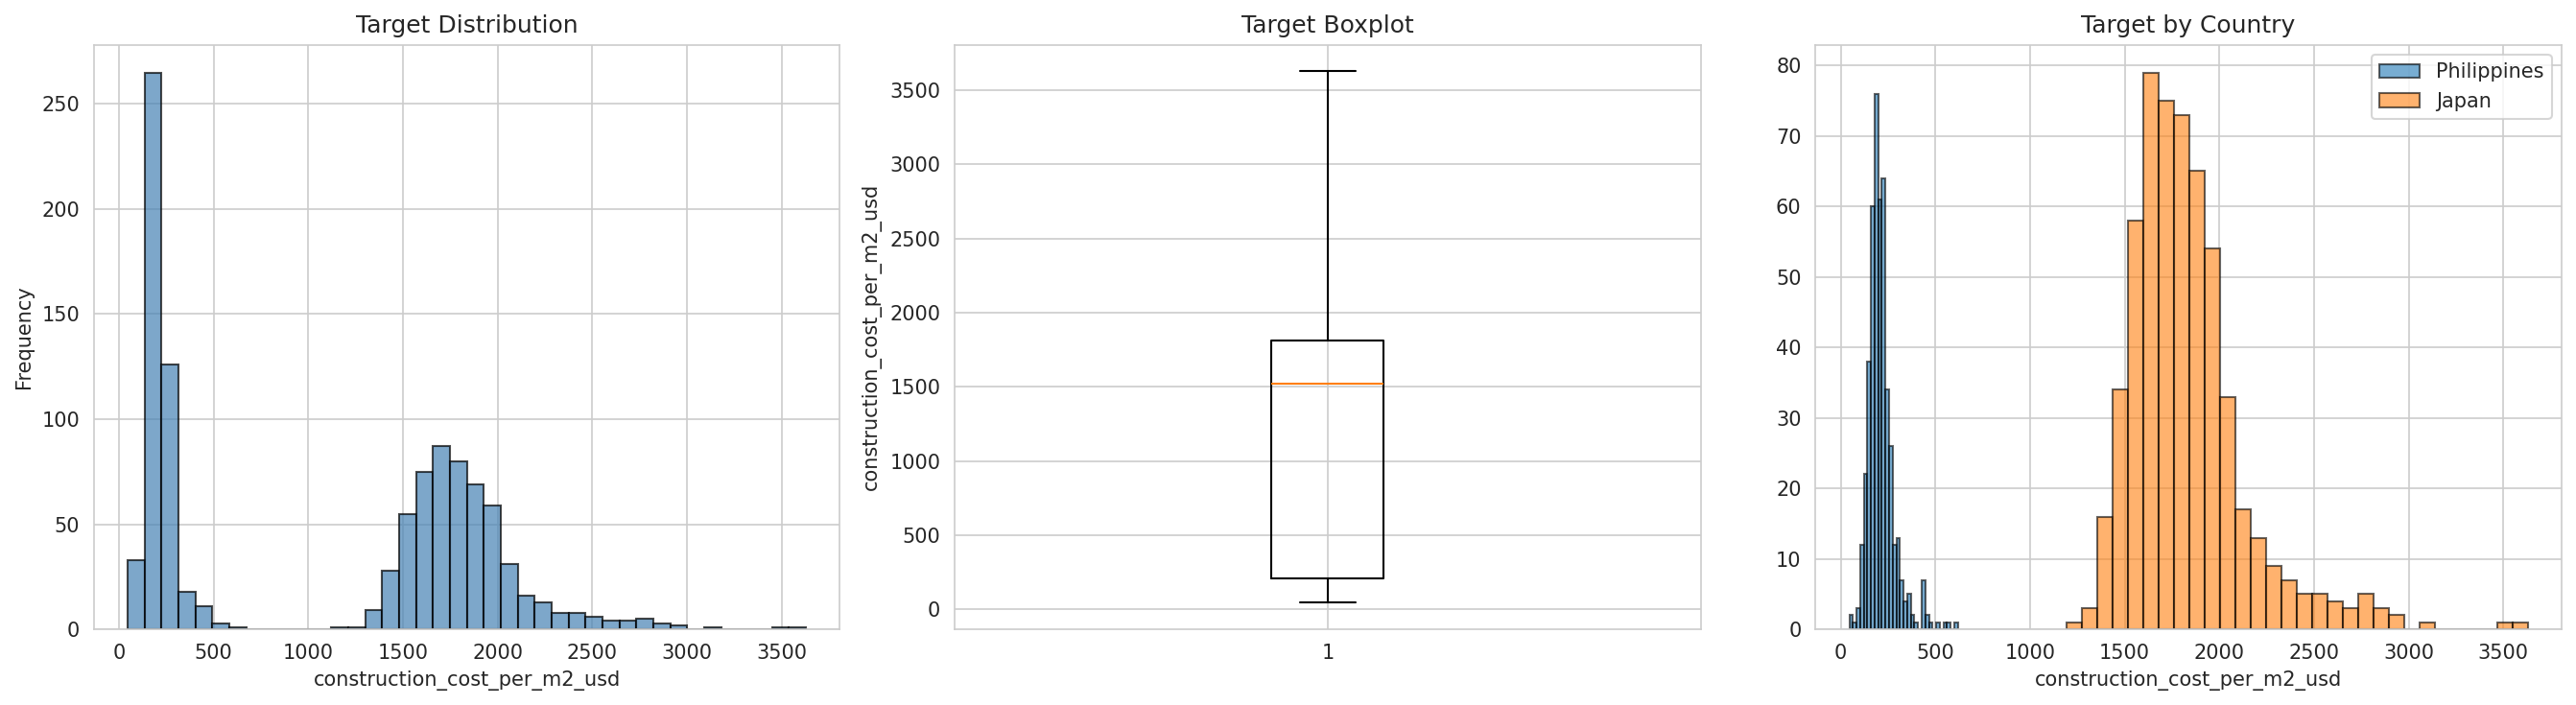


Target stats:
count    1024.000000
mean     1109.311486
std       837.074825
min        45.450769
25%       210.648077
50%      1521.307712
75%      1811.289875
max      3628.201594
Name: construction_cost_per_m2_usd, dtype: float64

Skewness: 0.040
Kurtosis: -1.518


In [ ]:
# ============================================================
# EDA: TARGET DISTRIBUTION
# ============================================================
TARGET = 'construction_cost_per_m2_usd'

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram
axes[0].hist(df[TARGET], bins=40, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_title('Target Distribution')
axes[0].set_xlabel(TARGET)
axes[0].set_ylabel('Frequency')

# Boxplot
axes[1].boxplot(df[TARGET], vert=True)
axes[1].set_title('Target Boxplot')
axes[1].set_ylabel(TARGET)

# By country
for country in df['country'].unique():
    subset = df[df['country'] == country][TARGET]
    axes[2].hist(subset, bins=30, alpha=0.6, label=country, edgecolor='black')
axes[2].set_title('Target by Country')
axes[2].set_xlabel(TARGET)
axes[2].legend()

plt.tight_layout()
plt.savefig('plots/eda_01_target_distribution.png', bbox_inches='tight')
plt.show()

print(f"\nTarget stats:\n{df[TARGET].describe()}")
print(f"\nSkewness: {df[TARGET].skew():.3f}")
print(f"Kurtosis: {df[TARGET].kurtosis():.3f}")

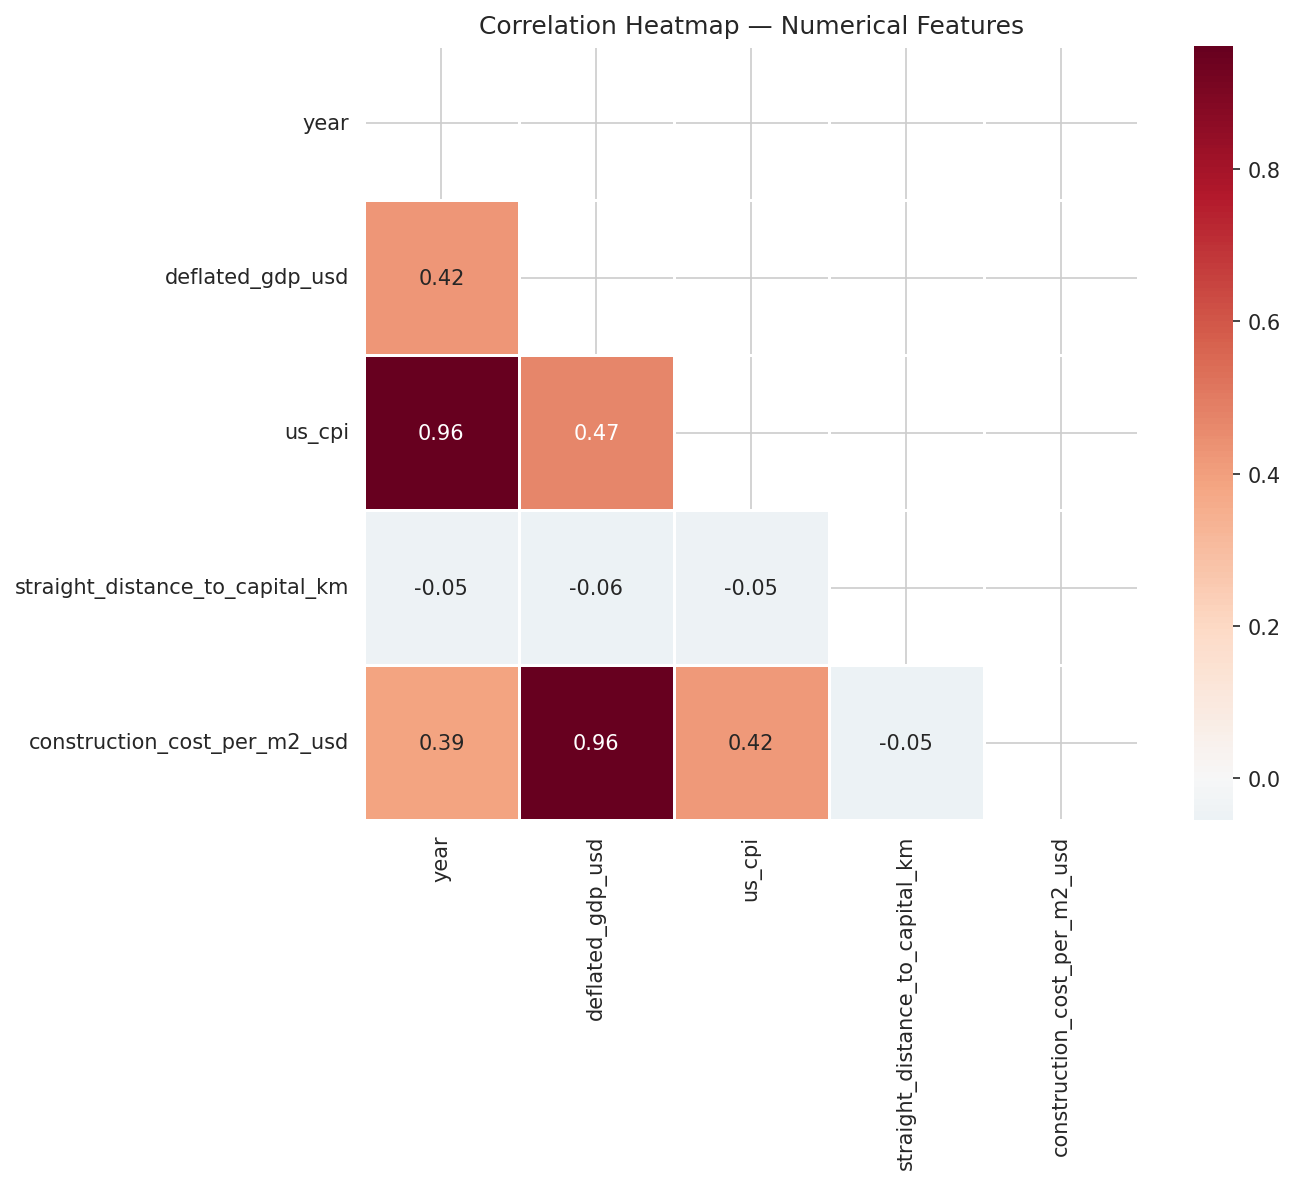

In [ ]:
# ============================================================
# EDA: CORRELATION HEATMAP (Numerical Features)
# ============================================================
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

fig, ax = plt.subplots(figsize=(10, 8))
corr_matrix = df[num_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Heatmap — Numerical Features')
plt.tight_layout()
plt.savefig('plots/eda_02_correlation_heatmap.png', bbox_inches='tight')
plt.show()

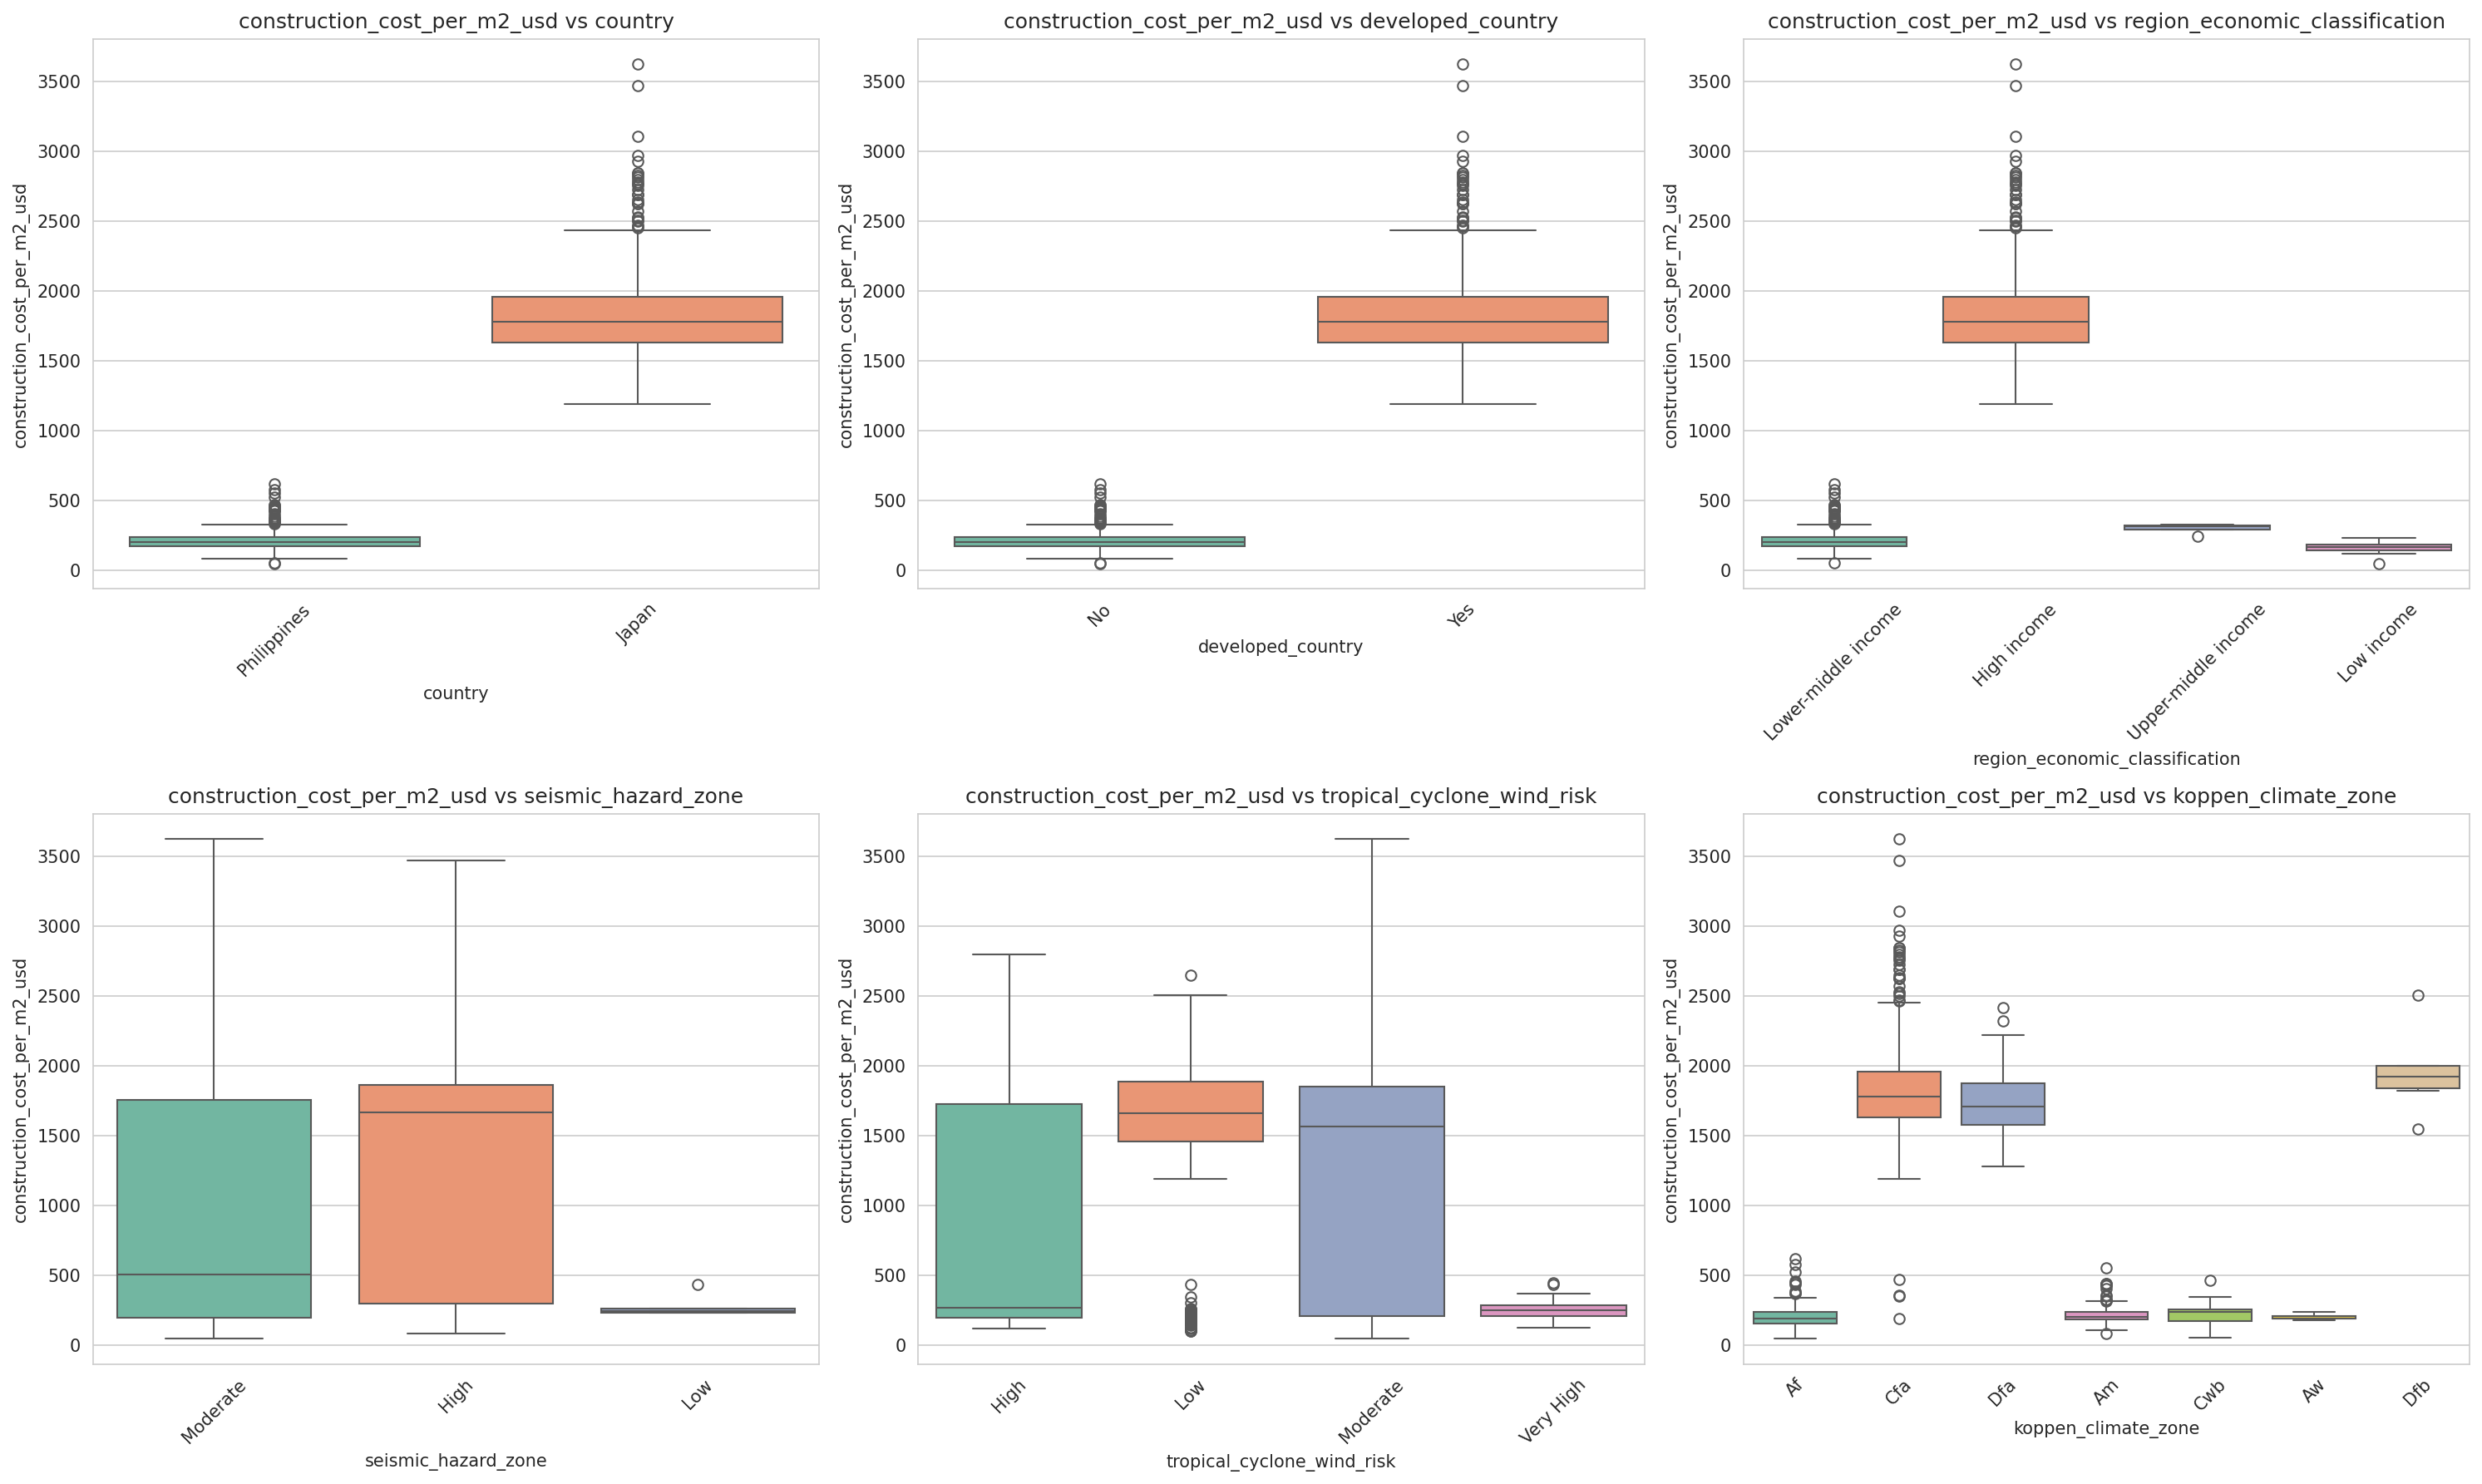

In [ ]:
# ============================================================
# EDA: TARGET vs KEY CATEGORICALS
# ============================================================
cat_cols_for_eda = ['country', 'developed_country', 'region_economic_classification',
                    'seismic_hazard_zone', 'tropical_cyclone_wind_risk', 'koppen_climate_zone']

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for i, col in enumerate(cat_cols_for_eda):
    sns.boxplot(data=df, x=col, y=TARGET, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{TARGET} vs {col}')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('plots/eda_03_target_vs_categoricals.png', bbox_inches='tight')
plt.show()

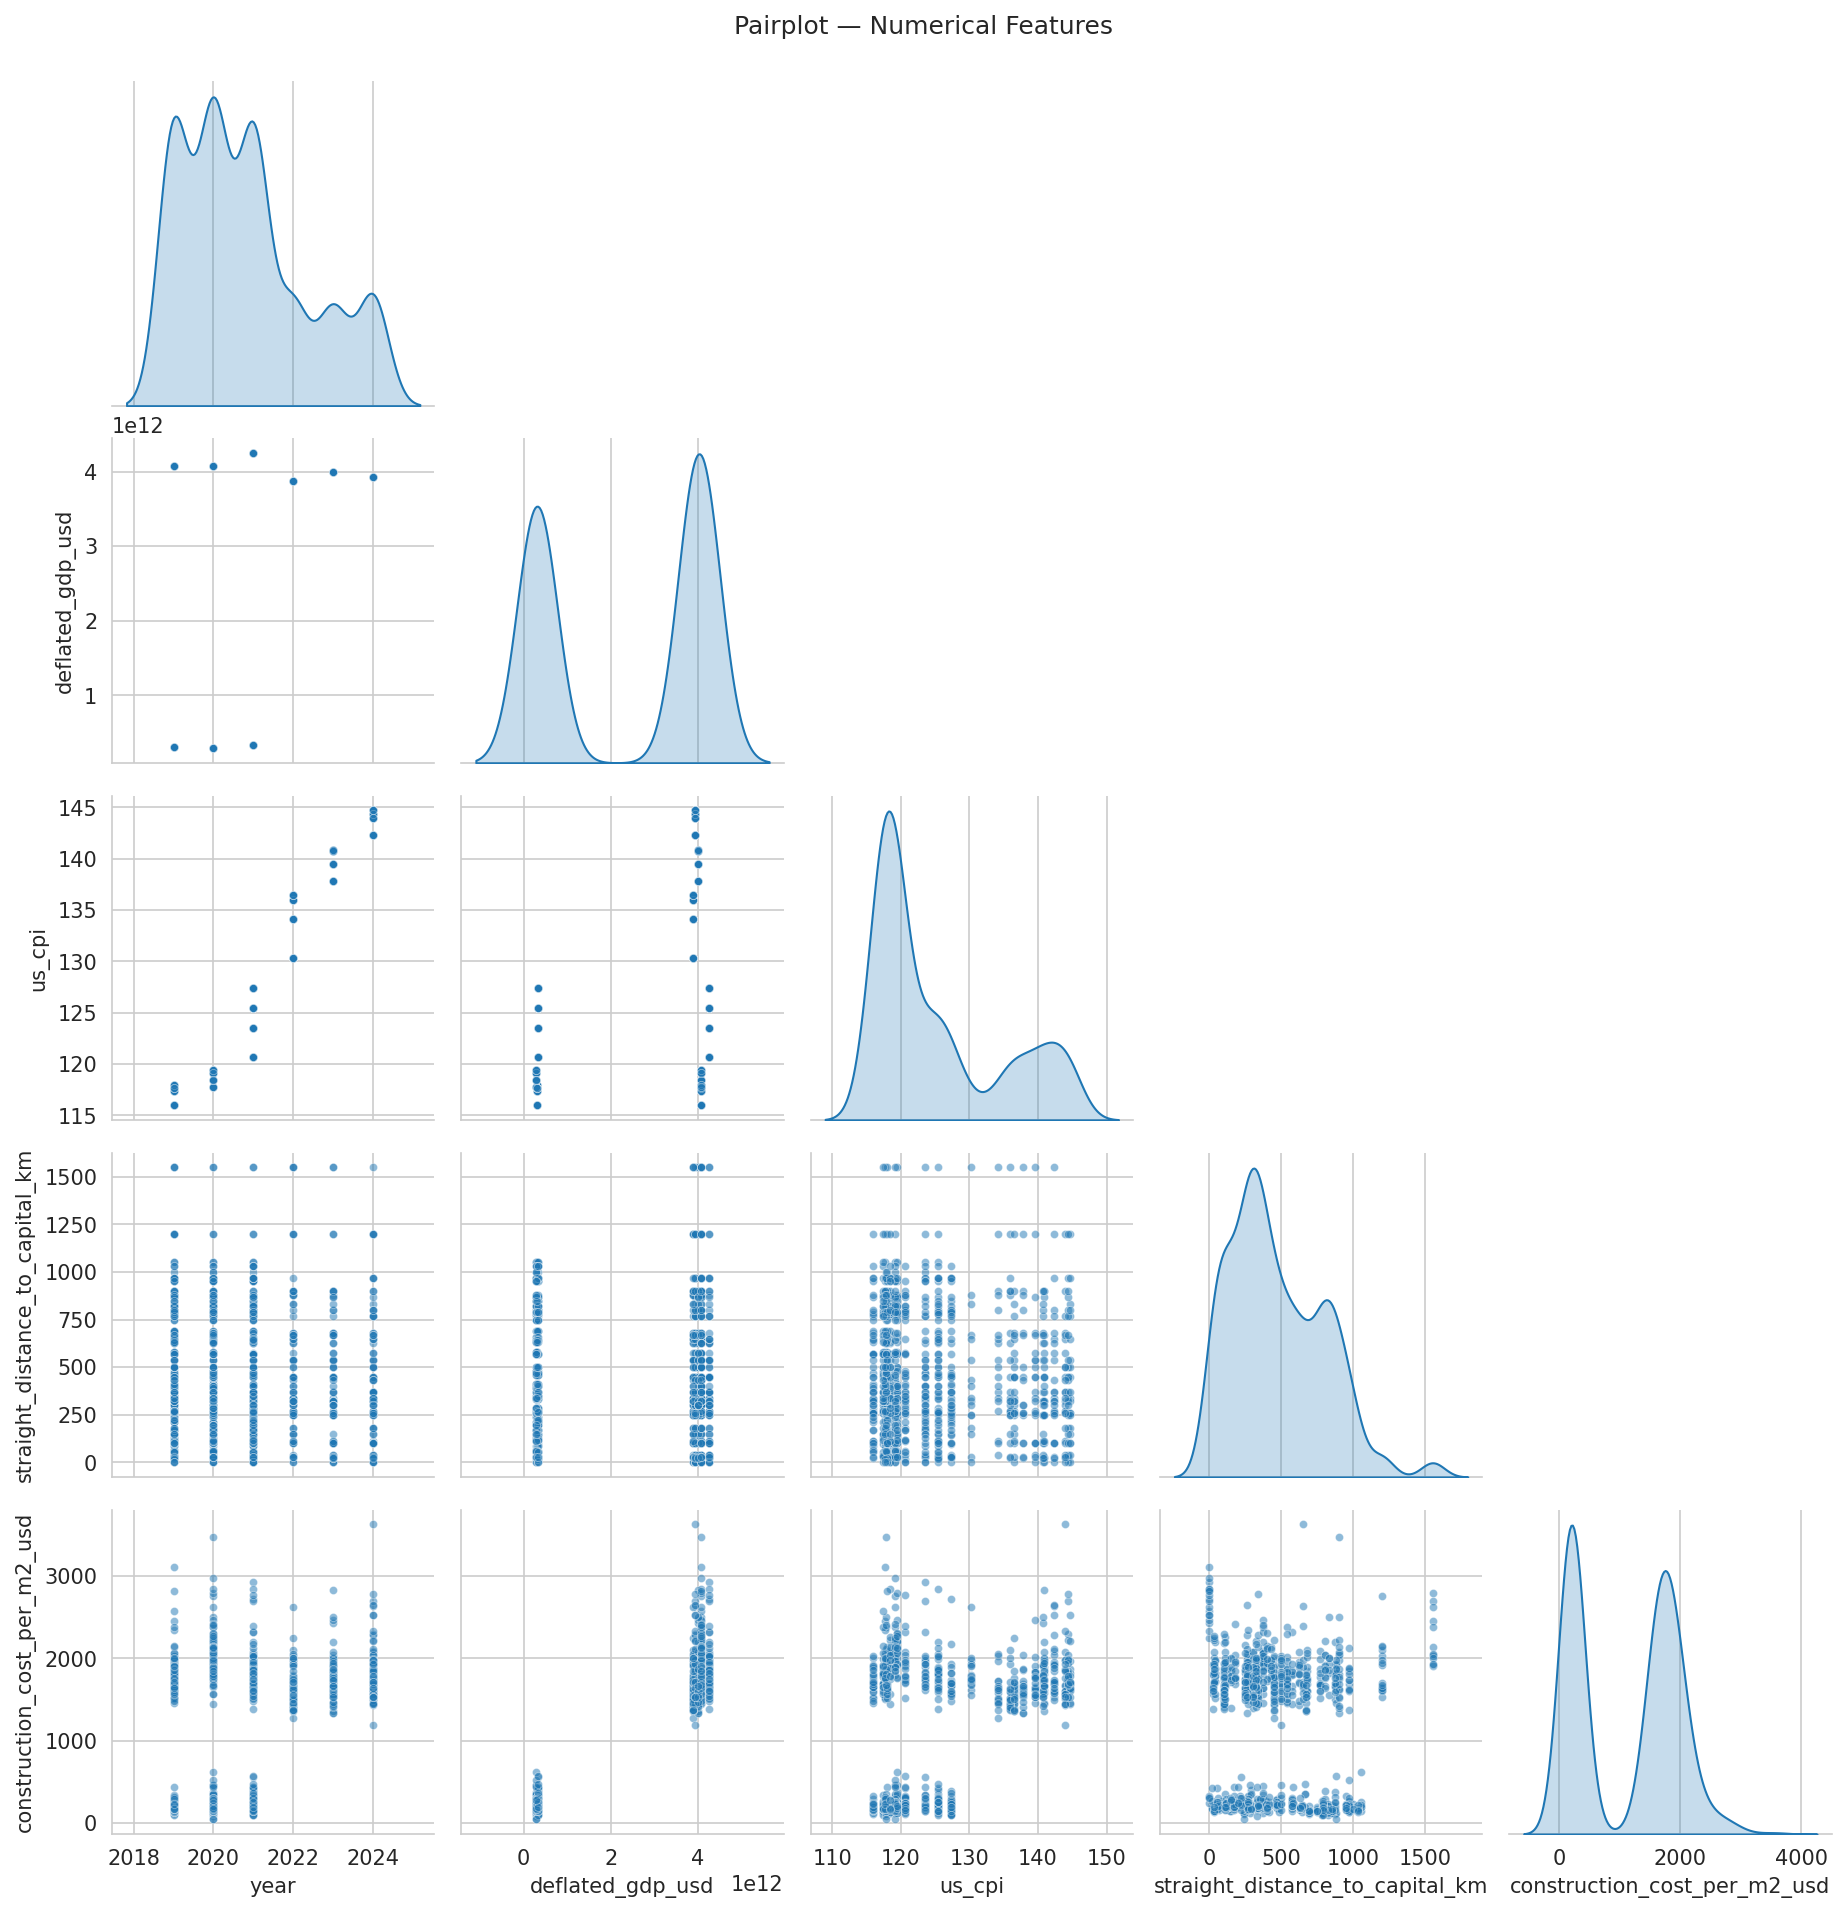

In [ ]:
# ============================================================
# EDA: PAIRPLOT — NUMERICAL FEATURES vs TARGET
# ============================================================
num_features = ['year', 'deflated_gdp_usd', 'us_cpi', 'straight_distance_to_capital_km', TARGET]
g = sns.pairplot(df[num_features], diag_kind='kde', plot_kws={'alpha': 0.5, 's': 15},
                 corner=True)
g.figure.suptitle('Pairplot — Numerical Features', y=1.02)
plt.savefig('plots/eda_04_pairplot_numerical.png', bbox_inches='tight')
plt.show()

In [ ]:
# ============================================================
# EDA: VALUE COUNTS FOR CATEGORICAL COLUMNS
# ============================================================
cat_cols = df.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    print(f"\n{'='*50}")
    print(f"{col} (unique={df[col].nunique()})")
    print('='*50)
    print(df[col].value_counts().head(15))


geolocation_name (unique=125)
geolocation_name
18000 Fukui        19
13000 Tokyo        18
42000 Nagasaki     17
16000 Toyama       17
25000 Shiga        17
14000 Kanagawa     16
26000 Kyoto        15
06000 Yamagata     14
12000 Chiba        14
24000 Mie          14
09000 Tochigi      14
08000 Ibaraki      14
03000 Iwate        13
19000 Yamanashi    13
15000 Niigata      13
Name: count, dtype: int64

quarter_label (unique=24)
quarter_label
2021-Q3    72
2019-Q3    70
2020-Q3    70
2020-Q2    69
2020-Q1    65
2019-Q1    62
2021-Q2    62
2019-Q2    62
2020-Q4    56
2021-Q4    56
2019-Q4    56
2021-Q1    53
2022-Q4    28
2024-Q1    27
2024-Q2    26
Name: count, dtype: int64

country (unique=2)
country
Japan          567
Philippines    457
Name: count, dtype: int64

developed_country (unique=2)
developed_country
Yes    567
No     457
Name: count, dtype: int64

landlocked (unique=2)
landlocked
No     794
Yes    230
Name: count, dtype: int64

region_economic_classification (unique=4)
region

## Phase 1.5: Feature Engineering

In [ ]:
# ============================================================
# FEATURE ENGINEERING
# ============================================================
# Extract quarter from quarter_label (e.g., '2019-Q3' → 3)
df['quarter'] = df['quarter_label'].str.extract(r'Q(\d)').astype(int)
df = df.drop(columns=['quarter_label'])

print(f"✅ Created 'quarter' column (values: {sorted(df['quarter'].unique())})")
print(f"✅ Dropped 'quarter_label'")
print(f"\nFinal columns ({len(df.columns)}): {list(df.columns)}")
print(f"Shape: {df.shape}")

✅ Created 'quarter' column (values: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)])
✅ Dropped 'quarter_label'

Final columns (20): ['geolocation_name', 'country', 'year', 'deflated_gdp_usd', 'us_cpi', 'developed_country', 'landlocked', 'region_economic_classification', 'access_to_airport', 'access_to_port', 'access_to_highway', 'access_to_railway', 'straight_distance_to_capital_km', 'seismic_hazard_zone', 'flood_risk_class', 'tropical_cyclone_wind_risk', 'tornadoes_wind_risk', 'koppen_climate_zone', 'construction_cost_per_m2_usd', 'quarter']
Shape: (1024, 20)


## Phase 2: Preprocessing Pipeline

In [ ]:
# ============================================================
# DEFINE COLUMN GROUPS & PREPROCESSING PIPELINE
# ============================================================
TARGET = 'construction_cost_per_m2_usd'

# Separate features and target
X = df.drop(columns=[TARGET])
y = df[TARGET]

# Column groups
numerical_cols = ['year', 'quarter', 'deflated_gdp_usd', 'us_cpi', 'straight_distance_to_capital_km']

binary_cols = ['developed_country', 'landlocked', 'access_to_airport',
               'access_to_port', 'access_to_highway', 'access_to_railway', 'flood_risk_class']

low_card_cat_cols = ['country', 'region_economic_classification', 'seismic_hazard_zone',
                     'tropical_cyclone_wind_risk', 'tornadoes_wind_risk', 'koppen_climate_zone']

high_card_cat_cols = ['geolocation_name']

print(f"Numerical ({len(numerical_cols)}):        {numerical_cols}")
print(f"Binary ({len(binary_cols)}):           {binary_cols}")
print(f"Low-card categorical ({len(low_card_cat_cols)}): {low_card_cat_cols}")
print(f"High-card categorical ({len(high_card_cat_cols)}): {high_card_cat_cols}")
print(f"\nTotal features: {len(numerical_cols) + len(binary_cols) + len(low_card_cat_cols) + len(high_card_cat_cols)}")
print(f"X shape: {X.shape}, y shape: {y.shape}")

# Build ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('bin', OrdinalEncoder(categories=[['No', 'Yes']] * len(binary_cols)), binary_cols),
        ('cat_low', OneHotEncoder(drop='first', handle_unknown='infrequent_if_exist',
                                   sparse_output=False), low_card_cat_cols),
        ('cat_high', TargetEncoder(random_state=RANDOM_STATE), high_card_cat_cols),
    ],
    remainder='drop',
    verbose_feature_names_out=True
)

print("\n✅ ColumnTransformer built successfully")

Numerical (5):        ['year', 'quarter', 'deflated_gdp_usd', 'us_cpi', 'straight_distance_to_capital_km']
Binary (7):           ['developed_country', 'landlocked', 'access_to_airport', 'access_to_port', 'access_to_highway', 'access_to_railway', 'flood_risk_class']
Low-card categorical (6): ['country', 'region_economic_classification', 'seismic_hazard_zone', 'tropical_cyclone_wind_risk', 'tornadoes_wind_risk', 'koppen_climate_zone']
High-card categorical (1): ['geolocation_name']

Total features: 19
X shape: (1024, 19), y shape: (1024,)

✅ ColumnTransformer built successfully


## Phase 3: Model Training & Hyperparameter Tuning

In [ ]:
# ============================================================
# DEFINE MODELS & HYPERPARAMETER SEARCH SPACES
# ============================================================
from scipy.stats import uniform, randint, loguniform

# GPU config for boosting models
# Note: LightGBM GPU requires OpenCL (not CUDA), so we keep it on CPU
xgb_device = {'device': 'cuda'} if HAS_GPU else {}
lgbm_device = {'verbose': -1}  # LightGBM stays on CPU (needs OpenCL, not CUDA)
catboost_device = {'task_type': 'GPU', 'verbose': 0} if HAS_GPU else {'verbose': 0}

models = {
    'Ridge': {
        'model': Ridge(random_state=RANDOM_STATE),
        'params': {
            'model__alpha': loguniform(1e-3, 1e3),
        }
    },
    'Lasso': {
        'model': Lasso(random_state=RANDOM_STATE, max_iter=10000),
        'params': {
            'model__alpha': loguniform(1e-4, 1e2),
        }
    },
    'ElasticNet': {
        'model': ElasticNet(random_state=RANDOM_STATE, max_iter=10000),
        'params': {
            'model__alpha': loguniform(1e-4, 1e2),
            'model__l1_ratio': uniform(0.1, 0.9),
        }
    },
    'SVR': {
        'model': SVR(),
        'params': {
            'model__C': loguniform(1e-1, 1e3),
            'model__epsilon': uniform(0.01, 0.5),
            'model__kernel': ['rbf', 'linear'],
        }
    },
    'RandomForest': {
        'model': RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
        'params': {
            'model__n_estimators': randint(100, 800),
            'model__max_depth': [None, 5, 10, 15, 20, 30],
            'model__min_samples_split': randint(2, 20),
            'model__min_samples_leaf': randint(1, 10),
        }
    },
    'GradientBoosting': {
        'model': GradientBoostingRegressor(random_state=RANDOM_STATE),
        'params': {
            'model__n_estimators': randint(100, 800),
            'model__max_depth': randint(3, 15),
            'model__learning_rate': loguniform(1e-3, 0.3),
            'model__subsample': uniform(0.6, 0.4),
        }
    },
    'XGBoost': {
        'model': XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1, **xgb_device),
        'params': {
            'model__n_estimators': randint(100, 800),
            'model__max_depth': randint(3, 15),
            'model__learning_rate': loguniform(1e-3, 0.3),
            'model__subsample': uniform(0.6, 0.4),
            'model__colsample_bytree': uniform(0.5, 0.5),
        }
    },
    'LightGBM': {
        'model': LGBMRegressor(random_state=RANDOM_STATE, n_jobs=-1, **lgbm_device),
        'params': {
            'model__n_estimators': randint(100, 800),
            'model__max_depth': randint(3, 15),
            'model__learning_rate': loguniform(1e-3, 0.3),
            'model__num_leaves': randint(20, 100),
            'model__subsample': uniform(0.6, 0.4),
        }
    },
    'CatBoost': {
        'model': CatBoostRegressor(random_state=RANDOM_STATE, **catboost_device),
        'params': {
            'model__iterations': randint(100, 800),
            'model__depth': randint(4, 10),
            'model__learning_rate': loguniform(1e-3, 0.3),
        }
    },
}

print(f"✅ {len(models)} models defined:")
for name in models:
    n_params = len(models[name]['params'])
    print(f"   • {name} ({n_params} hyperparameters)")

✅ 9 models defined:
   • Ridge (1 hyperparameters)
   • Lasso (1 hyperparameters)
   • ElasticNet (2 hyperparameters)
   • SVR (3 hyperparameters)
   • RandomForest (4 hyperparameters)
   • GradientBoosting (4 hyperparameters)
   • XGBoost (5 hyperparameters)
   • LightGBM (5 hyperparameters)
   • CatBoost (3 hyperparameters)


In [ ]:
# ============================================================
# TRAINING LOOP — RandomizedSearchCV for all models
# ============================================================
# This loop is RESUMABLE: if you re-run it, already-trained models are skipped.
# To force retrain a model, delete it from best_estimators: del best_estimators['ModelName']
# To retrain ALL, run: results, best_estimators, cv_detailed_results = {}, {}, {}

kf = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

# Initialize only if not already defined (enables resume)
if 'results' not in dir() or not isinstance(results, dict):
    results = {}
if 'best_estimators' not in dir() or not isinstance(best_estimators, dict):
    best_estimators = {}
if 'cv_detailed_results' not in dir() or not isinstance(cv_detailed_results, dict):
    cv_detailed_results = {}

remaining = {k: v for k, v in models.items() if k not in best_estimators}
print(f"Training {len(remaining)}/{len(models)} models ({len(best_estimators)} already done)...")
if best_estimators:
    print(f"   ✅ Already trained: {list(best_estimators.keys())}")
print("=" * 80)

for name, config in remaining.items():
    start_time = time.time()
    print(f"\n🔄 Training: {name}...")

    # Build pipeline
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', config['model'])
    ])

    # RandomizedSearchCV
    search = RandomizedSearchCV(
        pipe,
        param_distributions=config['params'],
        n_iter=N_ITER,
        cv=kf,
        scoring='neg_mean_squared_error',
        random_state=RANDOM_STATE,
        n_jobs=-1 if name not in ['XGBoost', 'CatBoost'] else 1,
        return_train_score=True,
        verbose=0
    )

    search.fit(X, y)

    # Store results
    best_estimators[name] = search.best_estimator_
    elapsed = time.time() - start_time

    # Get cross-validated predictions for further analysis
    cv_preds = cross_val_predict(search.best_estimator_, X, y, cv=kf)

    # Calculate metrics
    rmse = np.sqrt(mean_squared_error(y, cv_preds))
    mae = mean_absolute_error(y, cv_preds)
    r2 = r2_score(y, cv_preds)

    # Also store per-fold scores
    fold_scores = cross_val_score(search.best_estimator_, X, y, cv=kf,
                                   scoring='neg_mean_squared_error')
    fold_rmses = np.sqrt(-fold_scores)

    results[name] = {
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2,
        'Best_Params': search.best_params_,
        'CV_Preds': cv_preds,
        'Fold_RMSEs': fold_rmses,
        'Time_s': elapsed,
        'Search_CV_Results': pd.DataFrame(search.cv_results_),
    }

    cv_detailed_results[name] = search.cv_results_

    print(f"   ✅ {name}: RMSE={rmse:.4f} | MAE={mae:.4f} | R²={r2:.4f} | Time={elapsed:.1f}s")
    print(f"      Best params: { {k.replace('model__', ''): v for k, v in search.best_params_.items()} }")

print("\n" + "=" * 80)
print(f"\n🎉 All {len(best_estimators)} models trained! ({len(remaining)} new, {len(best_estimators) - len(remaining)} resumed)")

Training 2/9 models (7 already done)...
   ✅ Already trained: ['Ridge', 'Lasso', 'ElasticNet', 'SVR', 'RandomForest', 'GradientBoosting', 'XGBoost']

🔄 Training: LightGBM...


KeyboardInterrupt: 

In [ ]:
# ============================================================
# RESULTS COMPARISON TABLE
# ============================================================
results_df = pd.DataFrame({
    name: {
        'RMSE': r['RMSE'],
        'MAE': r['MAE'],
        'R²': r['R2'],
        'RMSE_std': r['Fold_RMSEs'].std(),
        'Time (s)': r['Time_s']
    }
    for name, r in results.items()
}).T.sort_values('RMSE')

results_df.index.name = 'Model'
print("\n📊 MODEL COMPARISON (sorted by RMSE):\n")
results_df.style.highlight_min(subset=['RMSE', 'MAE'], color='lightgreen') \
                .highlight_max(subset=['R²'], color='lightgreen') \
                .format({'RMSE': '{:.4f}', 'MAE': '{:.4f}', 'R²': '{:.4f}',
                         'RMSE_std': '{:.4f}', 'Time (s)': '{:.1f}'})

## Phase 4: Evaluation & Visualization

In [ ]:
# ============================================================
# PLOT 1: MODEL COMPARISON METRICS BAR CHART
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
sorted_models = results_df.index.tolist()

# RMSE
axes[0].barh(sorted_models, results_df['RMSE'], color='steelblue', edgecolor='black')
axes[0].set_xlabel('RMSE')
axes[0].set_title('RMSE by Model (lower is better)')
axes[0].invert_yaxis()

# MAE
axes[1].barh(sorted_models, results_df['MAE'], color='coral', edgecolor='black')
axes[1].set_xlabel('MAE')
axes[1].set_title('MAE by Model (lower is better)')
axes[1].invert_yaxis()

# R²
axes[2].barh(sorted_models, results_df['R²'], color='seagreen', edgecolor='black')
axes[2].set_xlabel('R²')
axes[2].set_title('R² by Model (higher is better)')
axes[2].invert_yaxis()

plt.tight_layout()
plt.savefig('plots/01_model_comparison_metrics.png', bbox_inches='tight', dpi=150)
plt.show()

In [ ]:
# ============================================================
# PLOT 2: HYPERPARAMETER TUNING CURVES
# ============================================================
# For each model, scatter plot of param value vs mean_test_score from RandomizedSearchCV

for name, r in results.items():
    cv_res = r['Search_CV_Results']
    param_cols = [c for c in cv_res.columns if c.startswith('param_model__')]

    if len(param_cols) == 0:
        continue

    n_params = len(param_cols)
    fig, axes = plt.subplots(1, n_params, figsize=(5 * n_params, 4))
    if n_params == 1:
        axes = [axes]

    for ax, param_col in zip(axes, param_cols):
        param_name = param_col.replace('param_model__', '')
        values = cv_res[param_col].values
        scores = np.sqrt(-cv_res['mean_test_score'].values)  # RMSE

        # Try to convert to float for scatter
        try:
            values_float = values.astype(float)
            ax.scatter(values_float, scores, alpha=0.6, edgecolors='black', s=40)
            # Trend line
            z = np.polyfit(values_float, scores, 2)
            p = np.poly1d(z)
            x_line = np.linspace(values_float.min(), values_float.max(), 100)
            ax.plot(x_line, p(x_line), 'r--', alpha=0.7, linewidth=2)
        except (ValueError, TypeError):
            # Categorical param — use boxplot-style
            unique_vals = list(set(values))
            positions = range(len(unique_vals))
            for j, val in enumerate(unique_vals):
                mask = values == val
                ax.scatter([j] * mask.sum(), scores[mask], alpha=0.6, edgecolors='black', s=40)
            ax.set_xticks(list(positions))
            ax.set_xticklabels(unique_vals, rotation=45)

        ax.set_xlabel(param_name)
        ax.set_ylabel('RMSE (CV)')
        ax.set_title(f'{name}: {param_name}')

    plt.suptitle(f'Hyperparameter Tuning — {name}', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig(f'plots/02_hyperparam_{name}.png', bbox_inches='tight', dpi=150)
    plt.show()

In [ ]:
# ============================================================
# PLOT 3: VALIDATION CURVES (Top 3 Models)
# ============================================================
top3 = results_df.index[:3].tolist()

# Define the key hyperparameter to sweep for validation curves
validation_param_map = {
    'Ridge': ('model__alpha', np.logspace(-3, 3, 20)),
    'Lasso': ('model__alpha', np.logspace(-4, 2, 20)),
    'ElasticNet': ('model__alpha', np.logspace(-4, 2, 20)),
    'SVR': ('model__C', np.logspace(-1, 3, 15)),
    'RandomForest': ('model__n_estimators', [50, 100, 200, 300, 400, 500, 600, 700]),
    'GradientBoosting': ('model__n_estimators', [50, 100, 200, 300, 400, 500, 600, 700]),
    'XGBoost': ('model__n_estimators', [50, 100, 200, 300, 400, 500, 600, 700]),
    'LightGBM': ('model__n_estimators', [50, 100, 200, 300, 400, 500, 600, 700]),
    'CatBoost': ('model__iterations', [50, 100, 200, 300, 400, 500, 600, 700]),
}

fig, axes = plt.subplots(1, len(top3), figsize=(7 * len(top3), 5))
if len(top3) == 1:
    axes = [axes]

for ax, name in zip(axes, top3):
    param_name, param_range = validation_param_map[name]
    pipe = best_estimators[name]

    try:
        train_scores, val_scores = validation_curve(
            pipe, X, y, param_name=param_name, param_range=param_range,
            cv=kf, scoring='neg_mean_squared_error', n_jobs=-1
        )
        train_rmse = np.sqrt(-train_scores)
        val_rmse = np.sqrt(-val_scores)

        ax.plot(param_range, train_rmse.mean(axis=1), 'o-', label='Train RMSE', color='steelblue')
        ax.fill_between(param_range, train_rmse.mean(axis=1) - train_rmse.std(axis=1),
                         train_rmse.mean(axis=1) + train_rmse.std(axis=1), alpha=0.15, color='steelblue')
        ax.plot(param_range, val_rmse.mean(axis=1), 'o-', label='Validation RMSE', color='coral')
        ax.fill_between(param_range, val_rmse.mean(axis=1) - val_rmse.std(axis=1),
                         val_rmse.mean(axis=1) + val_rmse.std(axis=1), alpha=0.15, color='coral')
        ax.set_xlabel(param_name.replace('model__', ''))
        ax.set_ylabel('RMSE')
        ax.set_title(f'Validation Curve — {name}')
        ax.legend()
        if param_name in ['model__alpha', 'model__C']:
            ax.set_xscale('log')
    except Exception as e:
        ax.text(0.5, 0.5, f'Error: {str(e)[:50]}', transform=ax.transAxes, ha='center')
        ax.set_title(f'Validation Curve — {name} (failed)')

plt.tight_layout()
plt.savefig('plots/03_validation_curves_top3.png', bbox_inches='tight', dpi=150)
plt.show()

In [ ]:
# ============================================================
# PLOT 4: LEARNING CURVES (Top 3 Models)
# ============================================================
fig, axes = plt.subplots(1, len(top3), figsize=(7 * len(top3), 5))
if len(top3) == 1:
    axes = [axes]

train_sizes_range = np.linspace(0.1, 1.0, 10)

for ax, name in zip(axes, top3):
    pipe = best_estimators[name]

    train_sizes, train_scores, val_scores = learning_curve(
        pipe, X, y, train_sizes=train_sizes_range, cv=kf,
        scoring='neg_mean_squared_error', n_jobs=-1, random_state=RANDOM_STATE
    )
    train_rmse = np.sqrt(-train_scores)
    val_rmse = np.sqrt(-val_scores)

    ax.plot(train_sizes, train_rmse.mean(axis=1), 'o-', label='Train RMSE', color='steelblue')
    ax.fill_between(train_sizes, train_rmse.mean(axis=1) - train_rmse.std(axis=1),
                     train_rmse.mean(axis=1) + train_rmse.std(axis=1), alpha=0.15, color='steelblue')
    ax.plot(train_sizes, val_rmse.mean(axis=1), 'o-', label='Validation RMSE', color='coral')
    ax.fill_between(train_sizes, val_rmse.mean(axis=1) - val_rmse.std(axis=1),
                     val_rmse.mean(axis=1) + val_rmse.std(axis=1), alpha=0.15, color='coral')
    ax.set_xlabel('Training Set Size')
    ax.set_ylabel('RMSE')
    ax.set_title(f'Learning Curve — {name}')
    ax.legend()

plt.tight_layout()
plt.savefig('plots/04_learning_curves_top3.png', bbox_inches='tight', dpi=150)
plt.show()

In [ ]:
# ============================================================
# PLOT 5-7: RESIDUAL ANALYSIS (Top 3 Models)
# ============================================================
for name in top3:
    cv_preds = results[name]['CV_Preds']
    residuals = y - cv_preds

    fig, axes = plt.subplots(1, 3, figsize=(20, 5))

    # Predicted vs Actual
    axes[0].scatter(y, cv_preds, alpha=0.5, edgecolors='black', s=20)
    min_val = min(y.min(), cv_preds.min())
    max_val = max(y.max(), cv_preds.max())
    axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Ideal')
    axes[0].set_xlabel('Actual')
    axes[0].set_ylabel('Predicted')
    axes[0].set_title(f'{name}: Predicted vs Actual')
    axes[0].legend()

    # Residuals vs Predicted
    axes[1].scatter(cv_preds, residuals, alpha=0.5, edgecolors='black', s=20)
    axes[1].axhline(y=0, color='r', linestyle='--', linewidth=2)
    axes[1].set_xlabel('Predicted')
    axes[1].set_ylabel('Residuals')
    axes[1].set_title(f'{name}: Residuals vs Predicted')

    # Residual distribution
    axes[2].hist(residuals, bins=40, edgecolor='black', alpha=0.7, color='steelblue', density=True)
    # KDE overlay
    x_range = np.linspace(residuals.min(), residuals.max(), 200)
    kde = stats.gaussian_kde(residuals)
    axes[2].plot(x_range, kde(x_range), 'r-', linewidth=2, label='KDE')
    axes[2].set_xlabel('Residuals')
    axes[2].set_ylabel('Density')
    axes[2].set_title(f'{name}: Residual Distribution')
    axes[2].legend()

    plt.suptitle(f'Residual Analysis — {name}', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig(f'plots/05_residual_analysis_{name}.png', bbox_inches='tight', dpi=150)
    plt.show()

    # Print stats
    print(f"{name} — Residual mean: {residuals.mean():.4f}, std: {residuals.std():.4f}, "
          f"skew: {residuals.skew():.3f}, kurtosis: {residuals.kurtosis():.3f}")

In [ ]:
# ============================================================
# PLOT 8: FEATURE IMPORTANCE
# ============================================================
# Get feature names from preprocessor
feature_names = preprocessor.get_feature_names_out()

tree_models = ['RandomForest', 'GradientBoosting', 'XGBoost', 'LightGBM', 'CatBoost']
linear_models = ['Ridge', 'Lasso', 'ElasticNet']

# Tree-based models
tree_available = [m for m in tree_models if m in best_estimators]
if tree_available:
    n_models = len(tree_available)
    fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 8))
    if n_models == 1:
        axes = [axes]

    for ax, name in zip(axes, tree_available):
        model = best_estimators[name].named_steps['model']
        importances = model.feature_importances_

        # Sort and take top 15
        indices = np.argsort(importances)[-15:]
        ax.barh(range(len(indices)), importances[indices], color='steelblue', edgecolor='black')
        ax.set_yticks(range(len(indices)))
        ax.set_yticklabels([feature_names[i].split('__')[-1] for i in indices])
        ax.set_xlabel('Importance')
        ax.set_title(f'{name}')

    plt.suptitle('Feature Importance — Tree-Based Models (Top 15)', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig('plots/08_feature_importance_tree.png', bbox_inches='tight', dpi=150)
    plt.show()

# Linear models
linear_available = [m for m in linear_models if m in best_estimators]
if linear_available:
    n_models = len(linear_available)
    fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 8))
    if n_models == 1:
        axes = [axes]

    for ax, name in zip(axes, linear_available):
        model = best_estimators[name].named_steps['model']
        coefs = np.abs(model.coef_)

        # Sort and take top 15
        indices = np.argsort(coefs)[-15:]
        ax.barh(range(len(indices)), coefs[indices], color='coral', edgecolor='black')
        ax.set_yticks(range(len(indices)))
        ax.set_yticklabels([feature_names[i].split('__')[-1] for i in indices])
        ax.set_xlabel('|Coefficient|')
        ax.set_title(f'{name}')

    plt.suptitle('Coefficient Magnitudes — Linear Models (Top 15)', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig('plots/08_feature_importance_linear.png', bbox_inches='tight', dpi=150)
    plt.show()

In [ ]:
# ============================================================
# PLOT 9: CUMULATIVE ERROR DISTRIBUTION CURVE
# ============================================================
fig, ax = plt.subplots(figsize=(12, 6))

colors = plt.cm.tab10(np.linspace(0, 1, len(results)))
for (name, r), color in zip(results.items(), colors):
    abs_errors = np.abs(y - r['CV_Preds'])
    sorted_errors = np.sort(abs_errors)
    cumulative = np.arange(1, len(sorted_errors) + 1) / len(sorted_errors) * 100

    ax.plot(sorted_errors, cumulative, label=f"{name} (MAE={r['MAE']:.1f})",
            linewidth=2, color=color)

ax.set_xlabel('Absolute Error (USD/m²)')
ax.set_ylabel('% of Predictions Within Error')
ax.set_title('Cumulative Error Distribution — All Models')
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xlim(left=0)
ax.set_ylim(0, 100)

# Add reference lines at 50%, 90%, 95%
for pct in [50, 90, 95]:
    ax.axhline(y=pct, color='gray', linestyle=':', alpha=0.5)
    ax.text(ax.get_xlim()[1] * 0.95, pct + 1, f'{pct}%', ha='right', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig('plots/09_cumulative_error_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

In [ ]:
# ============================================================
# PLOT 10: PREDICTION ERROR PLOT (Top 3 Models)
# ============================================================
fig, axes = plt.subplots(1, len(top3), figsize=(7 * len(top3), 6))
if len(top3) == 1:
    axes = [axes]

for ax, name in zip(axes, top3):
    cv_preds = results[name]['CV_Preds']

    ax.scatter(y, cv_preds, alpha=0.5, edgecolors='black', s=20, zorder=3)

    # Perfect prediction line
    min_val = min(y.min(), cv_preds.min())
    max_val = max(y.max(), cv_preds.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect', zorder=4)

    # Best fit line
    z = np.polyfit(y, cv_preds, 1)
    p = np.poly1d(z)
    x_line = np.linspace(min_val, max_val, 100)
    ax.plot(x_line, p(x_line), 'b-', linewidth=1.5, alpha=0.7, label=f'Best fit (slope={z[0]:.2f})', zorder=4)

    ax.set_xlabel('Actual (USD/m²)')
    ax.set_ylabel('Predicted (USD/m²)')
    ax.set_title(f'Prediction Error — {name} (R²={results[name]["R2"]:.4f})')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('plots/10_prediction_error_top3.png', bbox_inches='tight', dpi=150)
plt.show()

In [ ]:
# ============================================================
# PLOT 11: CROSS-VALIDATION FOLD-WISE BOX PLOTS
# ============================================================
fig, ax = plt.subplots(figsize=(14, 6))

fold_data = []
fold_labels = []
for name in results_df.index:
    fold_data.append(results[name]['Fold_RMSEs'])
    fold_labels.append(name)

bp = ax.boxplot(fold_data, labels=fold_labels, patch_artist=True, showmeans=True,
                meanprops=dict(marker='D', markerfacecolor='red', markersize=6))

colors = plt.cm.Set2(np.linspace(0, 1, len(fold_data)))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_ylabel('RMSE')
ax.set_title('CV Fold-wise RMSE Distribution (stability across folds)')
ax.tick_params(axis='x', rotation=45)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('plots/11_cv_fold_scores_boxplot.png', bbox_inches='tight', dpi=150)
plt.show()

In [ ]:
# ============================================================
# PLOT 12: MODEL PREDICTION CORRELATION HEATMAP
# ============================================================
pred_df = pd.DataFrame({name: results[name]['CV_Preds'] for name in results})
pred_corr = pred_df.corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(pred_corr, dtype=bool), k=1)
sns.heatmap(pred_corr, annot=True, fmt='.3f', cmap='YlOrRd', ax=ax,
            mask=mask, square=True, linewidths=0.5, vmin=0.8, vmax=1.0)
ax.set_title('Model Prediction Correlation (useful for ensembling)')
plt.tight_layout()
plt.savefig('plots/12_model_prediction_correlation.png', bbox_inches='tight', dpi=150)
plt.show()

print("💡 Models with LOW correlation between predictions are good ensemble candidates.")

## Phase 5: Model Persistence & Reusability

In [ ]:
# ============================================================
# SAVE ALL TRAINED MODELS & RESULTS
# ============================================================
print("Saving all models to saved_models/ ...\n")

for name, estimator in best_estimators.items():
    filepath = f'saved_models/{name}.joblib'
    joblib.dump(estimator, filepath)
    size_mb = os.path.getsize(filepath) / (1024 * 1024)
    print(f"   ✅ {filepath} ({size_mb:.1f} MB)")

# Save results summary
results_export = results_df.copy()
results_export['Best_Params'] = [
    str({k.replace('model__', ''): v for k, v in results[name]['Best_Params'].items()})
    for name in results_export.index
]
results_export.to_csv('saved_models/results_summary.csv')
print(f"\n   ✅ saved_models/results_summary.csv")

# Save best model name
best_model_name = results_df.index[0]
with open('saved_models/best_model.txt', 'w') as f:
    f.write(best_model_name)
print(f"\n🏆 Best model: {best_model_name} (RMSE={results_df.loc[best_model_name, 'RMSE']:.4f})")
print(f"\n📁 All files saved to saved_models/")
print(f"📊 All plots saved to plots/")

In [ ]:
# ============================================================
# UTILITY: LOAD A SAVED MODEL & PREDICT ON NEW DATA
# ============================================================
# This cell is STANDALONE — you can restart the kernel and run
# only this cell to load a trained model and make predictions.
# No retraining needed!

import pandas as pd
import joblib
import os

# --- Configuration ---
MODEL_NAME = 'best'  # Change to any model name: 'Ridge', 'XGBoost', 'LightGBM', etc.
                      # Use 'best' to auto-load the best model

# --- Load model ---
if MODEL_NAME == 'best':
    with open('saved_models/best_model.txt', 'r') as f:
        MODEL_NAME = f.read().strip()
    print(f"Auto-loading best model: {MODEL_NAME}")

pipeline = joblib.load(f'saved_models/{MODEL_NAME}.joblib')
print(f"✅ Loaded: saved_models/{MODEL_NAME}.joblib")

# --- Load results ---
results_summary = pd.read_csv('saved_models/results_summary.csv', index_col=0)
print(f"\n📊 Model performance:")
print(results_summary.loc[[MODEL_NAME], ['RMSE', 'MAE', 'R²']])

# --- Predict on evaluation set ---
eval_df = pd.read_csv('evaluation_tabular_no_target.csv')
eval_df = eval_df.drop(columns=['data_id', 'sentinel2_tiff_file_name', 'viirs_tiff_file_name'])
eval_df['quarter'] = eval_df['quarter_label'].str.extract(r'Q(\d)').astype(int)
eval_df = eval_df.drop(columns=['quarter_label'])

predictions = pipeline.predict(eval_df)

print(f"\n🔮 Predictions shape: {predictions.shape}")
print(f"   Min: {predictions.min():.2f} | Max: {predictions.max():.2f} | Mean: {predictions.mean():.2f}")

# Save predictions
pred_df = pd.read_csv('evaluation_tabular_no_target.csv')[['data_id']]
pred_df['construction_cost_per_m2_usd'] = predictions
pred_df.to_csv(f'predictions_{MODEL_NAME}.csv', index=False)
print(f"\n💾 Saved: predictions_{MODEL_NAME}.csv")
pred_df.head(10)

In [ ]:
# ============================================================
# SUMMARY: ALL SAVED ARTIFACTS
# ============================================================
print("📁 SAVED MODELS:")
for f in sorted(os.listdir('saved_models')):
    size = os.path.getsize(f'saved_models/{f}') / (1024 * 1024)
    print(f"   saved_models/{f} ({size:.1f} MB)")

print(f"\n📊 SAVED PLOTS:")
for f in sorted(os.listdir('plots')):
    size = os.path.getsize(f'plots/{f}') / (1024)
    print(f"   plots/{f} ({size:.0f} KB)")

print(f"\n✅ Total: {len(os.listdir('saved_models'))} model files, {len(os.listdir('plots'))} plots")